   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.5/152.5 kB 2.3 MB/s eta 0:00:00
Using device: cpu


Saving amplifier_dataset_all_updated (2).csv to amplifier_dataset_all_updated (2) (1).csv
Config map: {'CC': 0, 'CE': 1, 'CG': 2}
Epoch 000 | D: 100.0000 | G: 0.0000
Epoch 030 | D: 100.0000 | G: 0.0000
Epoch 060 | D: 100.0000 | G: 0.0000
Epoch 090 | D: 100.0000 | G: 0.0000

Available Configs: ['CC', 'CE', 'CG']
Enter Config (CE / CC / CG): CE
Enter Gain: 20
Enter Vcc: 12

=== GENERATED RESULTS ===


,Parameter,Value
0,Vout (V),6.004488
1,RC (Ω),5910.130371
2,RE (Ω),592.835938
3,RG (Ω),121942.859375
4,Calculated Gain,9.565857



Requested Gain: 20.0
Theoretical Estimated Gain: 9.57


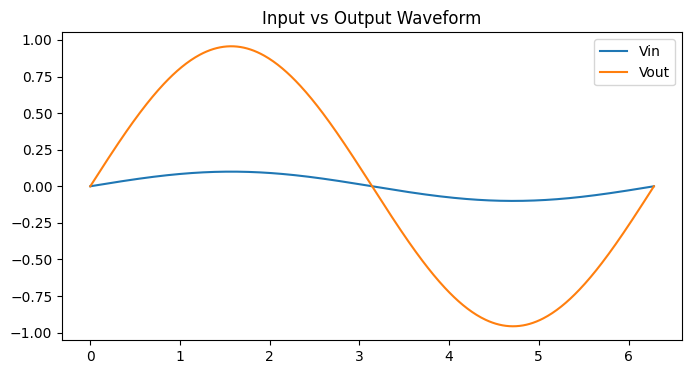

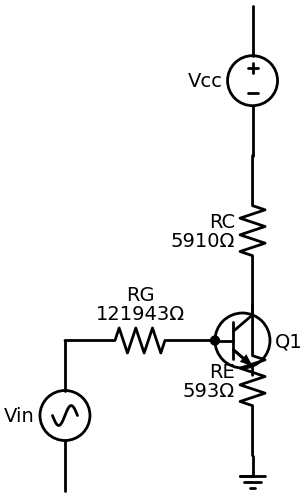

In [1]:
# ============================================================
# FINAL RESEARCH-GRADE GEN-AI AMPLIFIER DESIGN SYSTEM
# Topology-Aware Conditional GAN + Gain Validation + Waveform
# ============================================================

!pip install schemdraw -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import schemdraw
import schemdraw.elements as elm

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- LOAD DATA ----------------
from google.colab import files
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]
data = pd.read_csv(csv_file)

# ---------------- ENCODE CONFIG ----------------
le = LabelEncoder()
data["Config_enc"] = le.fit_transform(data["Config"])
config_map = {cls: int(le.transform([cls])[0]) for cls in le.classes_}
print("Config map:", config_map)

# ---------------- CONDITIONS ----------------
C = data[["Config_enc", "Gain", "Vcc"]].values.astype(np.float32)
c_scaler = StandardScaler()
C_scaled = c_scaler.fit_transform(C).astype(np.float32)
C_tensor = torch.tensor(C_scaled, dtype=torch.float32)

# ---------------- PARAMETERS ----------------
X = data[["Vout", "RC", "RE", "RG"]].values.astype(np.float32)
X_tensor = torch.tensor(X, dtype=torch.float32)

loader = DataLoader(
    TensorDataset(X_tensor, C_tensor),
    batch_size=64,
    shuffle=True
)

C_SCALE = torch.tensor(c_scaler.scale_, dtype=torch.float32, device=device)
C_MEAN  = torch.tensor(c_scaler.mean_,  dtype=torch.float32, device=device)

# ============================================================
# GENERATOR (TOPOLOGY-AWARE)
# ============================================================

class Generator(nn.Module):
    def __init__(self, noise_dim, cond_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 4),
            nn.Sigmoid()
        )

    def forward(self, z, c):
        x = self.net(torch.cat([z, c], dim=1))
        Cun = c * C_SCALE + C_MEAN
        cfg = Cun[:,0].long()
        Vcc = Cun[:,2]

        Vout = torch.zeros_like(Vcc)
        RC   = torch.zeros_like(Vcc)
        RE   = torch.zeros_like(Vcc)
        RG   = torch.zeros_like(Vcc)

        for i in range(len(cfg)):

            if cfg[i] == config_map["CE"]:
                RC[i]   = 1000 + x[i,1]*9000
                RE[i]   = 200  + x[i,2]*800
                RG[i]   = 20000 + x[i,3]*180000
                Vout[i] = 0.45*Vcc[i] + x[i,0]*0.1*Vcc[i]

            elif cfg[i] == config_map["CC"]:
                RC[i]   = 0
                RE[i]   = 200 + x[i,2]*800
                RG[i]   = 20000 + x[i,3]*180000
                Vout[i] = Vcc[i] - 0.7

            elif cfg[i] == config_map["CG"]:
                RC[i]   = 2000 + x[i,1]*8000
                RE[i]   = 100 + x[i,2]*200
                RG[i]   = 20000 + x[i,3]*180000
                Vout[i] = 0.5*Vcc[i] + x[i,0]*0.2*Vcc[i]

        return torch.stack([Vout, RC, RE, RG], dim=1)

# ============================================================
# DISCRIMINATOR
# ============================================================

class Discriminator(nn.Module):
    def __init__(self, cond_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4 + cond_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x, c):
        return self.net(torch.cat([x, c], dim=1))

# ---------------- INIT ----------------
noise_dim = 16
G = Generator(noise_dim, C_tensor.shape[1]).to(device)
D = Discriminator(C_tensor.shape[1]).to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=1e-4)
opt_D = torch.optim.Adam(D.parameters(), lr=1e-4)
criterion = nn.BCELoss()

# ============================================================
# TRAINING
# ============================================================

epochs = 120
for epoch in range(epochs):
    for real_x, c in loader:
        real_x = real_x.to(device)
        c = c.to(device)

        batch = real_x.size(0)
        valid = torch.ones(batch,1, device=device)
        fake  = torch.zeros(batch,1, device=device)

        z = torch.randn(batch, noise_dim, device=device)
        fake_x = G(z, c)

        loss_D = criterion(D(real_x, c), valid) + \
                 criterion(D(fake_x.detach(), c), fake)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        loss_G = criterion(D(fake_x, c), valid)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    if epoch % 30 == 0:
        print(f"Epoch {epoch:03d} | D: {loss_D.item():.4f} | G: {loss_G.item():.4f}")

# ============================================================
# INTERACTIVE TEST
# ============================================================

print("\nAvailable Configs:", list(config_map.keys()))
cfg  = input("Enter Config (CE / CC / CG): ")
gain = float(input("Enter Gain: "))
vcc  = float(input("Enter Vcc: "))

cfg_val = config_map[cfg]
cond = np.array([[cfg_val, gain, vcc]], dtype=np.float32)
cond_scaled = c_scaler.transform(cond).astype(np.float32)
cond_tensor = torch.tensor(cond_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    z = torch.randn(1, noise_dim, device=device)
    gen = G(z, cond_tensor).cpu().numpy()

Vout, RC, RE, RG = gen[0]

# ============================================================
# GAIN CALCULATION
# ============================================================

re_small = 25  # intrinsic emitter resistance approx
if cfg == "CE":
    gain_calc = RC / (RE + re_small)
elif cfg == "CC":
    gain_calc = RE / (RE + re_small)
elif cfg == "CG":
    gain_calc = RC / re_small

# ============================================================
# DISPLAY RESULTS TABLE
# ============================================================

results = pd.DataFrame({
    "Parameter": ["Vout (V)", "RC (Ω)", "RE (Ω)", "RG (Ω)", "Calculated Gain"],
    "Value": [Vout, RC, RE, RG, gain_calc]
})

print("\n=== GENERATED RESULTS ===")
display(results)

print(f"\nRequested Gain: {gain}")
print(f"Theoretical Estimated Gain: {gain_calc:.2f}")

# ============================================================
# WAVEFORM PLOT
# ============================================================

t = np.linspace(0, 2*np.pi, 500)
Vin_amp = 0.1
Vin = Vin_amp * np.sin(t)
Vout_wave = gain_calc * Vin

plt.figure(figsize=(8,4))
plt.plot(t, Vin, label="Vin")
plt.plot(t, Vout_wave, label="Vout")
plt.title("Input vs Output Waveform")
plt.legend()
plt.show()

# ============================================================
# PROFESSIONAL CIRCUIT DIAGRAM
# ============================================================

def draw_ce():
    with schemdraw.Drawing() as d:
        d += elm.SourceSin().label('Vin')
        d += elm.Resistor().right().label(f'RG\n{RG:.0f}Ω')
        d += elm.Dot()
        d += elm.BjtNpn(circle=True).right().label('Q1')
        d.push()
        d += elm.Resistor().up().label(f'RC\n{RC:.0f}Ω')
        d += elm.SourceV().up().label('Vcc')
        d.pop()
        d += elm.Resistor().down().label(f'RE\n{RE:.0f}Ω')
        d += elm.Ground()
        d.draw()

def draw_cc():
    with schemdraw.Drawing() as d:
        d += elm.SourceSin().label('Vin')
        d += elm.Resistor().right().label(f'RG\n{RG:.0f}Ω')
        d += elm.Dot()
        d += elm.BjtNpn(circle=True).right().label('Q1')
        d.push()
        d += elm.Line().up()
        d += elm.SourceV().up().label('Vcc')
        d.pop()
        d += elm.Resistor().down().label(f'RE\n{RE:.0f}Ω')
        d += elm.Ground()
        d.draw()

def draw_cg():
    with schemdraw.Drawing() as d:
        d += elm.SourceSin().label('Vin')
        d += elm.Resistor().right().label(f'RE\n{RE:.0f}Ω')
        d += elm.Dot()
        d += elm.BjtNpn(circle=True).right().label('Q1')
        d.push()
        d += elm.Line().down()
        d += elm.Ground()
        d.pop()
        d += elm.Resistor().up().label(f'RC\n{RC:.0f}Ω')
        d += elm.SourceV().up().label('Vcc')
        d.draw()

if cfg == "CE":
    draw_ce()
elif cfg == "CC":
    draw_cc()
elif cfg == "CG":
    draw_cg()
